# Benchmark STAR junctions: STAR SJ.out.tab vs get_star_junctions.py

## imports

In [1]:
import os
import yaml
import pandas as pd
from scipy.stats import pearsonr

import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

FIGS_DIR = os.path.join("pdfs","benchmark_get_star_junctions")
os.makedirs(FIGS_DIR, exist_ok=True)

## data

In [2]:
# paths

ROOT = ".."
RAW_DIR = os.path.join(ROOT,"data","raw")
config = yaml.safe_load(open(os.path.join(ROOT,"config","config.yaml"),"r"))
SAMPLES = config["preprocessing"]["overfitting"]["samples"]
JUNCTIONS_DIR = os.path.join(ROOT,"results","sanity_checks","comparison_ssu","junctions")

star_files = {
    s: os.path.join(RAW_DIR,"ENA","sf3b1mut","STAR","{sample}","paper_pass.SJ.out.tab").format(sample=s)
    for s in SAMPLES
}
custom_files = {
    s: os.path.join(JUNCTIONS_DIR,"{sample}.starlike.SJ.out.tab").format(sample=s)
    for s in SAMPLES
}

In [3]:
# loads

SJ_COLS = ["chrom","intron_start","intron_end","strand_code","intron_motif","annotated","n_unique","n_multi","max_overhang"]

star = pd.concat([
    pd.read_table(f, header=None, names=SJ_COLS).assign(sample=s)
    for s, f in star_files.items()
])

custom = pd.concat([
    pd.read_table(f, header=None, names=SJ_COLS).assign(sample=s)
    for s, f in custom_files.items()
])

## equivalence

In [4]:
star.shape

(625198, 10)

In [5]:
custom.shape

(62904, 10)

In [6]:
star

,chrom,intron_start,intron_end,strand_code,intron_motif,annotated,n_unique,n_multi,max_overhang,sample
0,chr1,11845,12009,1,1,0,0,1,61,SRR17111303
1,chr1,13115,183634,1,1,0,1,2,26,SRR17111303
2,chr1,14830,14969,2,2,1,49,153,62,SRR17111303
3,chr1,14830,15795,2,2,0,0,1,15,SRR17111303
4,chr1,14830,186316,2,2,0,0,3,60,SRR17111303
...,...,...,...,...,...,...,...,...,...,...
326201,KI270751.1,50687,51267,1,1,0,0,1,49,SRR17111311
326202,KI270751.1,71499,72909,2,2,0,0,1,57,SRR17111311
326203,KI270751.1,71499,73425,2,2,0,0,3,40,SRR17111311
326204,KI270751.1,71499,73509,2,2,0,0,2,51,SRR17111311


In [7]:
star.query("chrom == 'chr1' and intron_start == 14830")

,chrom,intron_start,intron_end,strand_code,intron_motif,annotated,n_unique,n_multi,max_overhang,sample
2,chr1,14830,14969,2,2,1,49,153,62,SRR17111303
3,chr1,14830,15795,2,2,0,0,1,15,SRR17111303
4,chr1,14830,186316,2,2,0,0,3,60,SRR17111303
4,chr1,14830,14969,2,2,1,28,145,62,SRR17111311


In [8]:
custom.query("chrom == 'chr1' and intron_start == 14830")

,chrom,intron_start,intron_end,strand_code,intron_motif,annotated,n_unique,n_multi,max_overhang,sample
2,chr1,14830,14969,2,0,0,50,229,124,SRR17111303
3,chr1,14830,15795,2,0,0,0,1,110,SRR17111303
4,chr1,14830,186316,2,0,0,0,4,110,SRR17111303
5,chr1,14830,185541,2,0,0,0,1,85,SRR17111303
6,chr1,14830,14977,2,0,0,0,2,69,SRR17111303
4,chr1,14830,14969,2,0,0,29,223,124,SRR17111311
5,chr1,14830,14962,2,0,0,1,3,76,SRR17111311
6,chr1,14830,185483,2,0,0,0,2,76,SRR17111311


In [9]:
KEY = ["sample","chrom","intron_start","intron_end","strand_code"]

X = pd.merge(
    star[KEY + ["n_unique","n_multi"]].rename(columns={"n_unique":"n_unique_star","n_multi":"n_multi_star"}),
    custom[KEY + ["n_unique","n_multi"]].rename(columns={"n_unique":"n_unique_custom","n_multi":"n_multi_custom"}),
    on=KEY,
    how="inner"
)

X["diff_n_unique"] = X["n_unique_star"] - X["n_unique_custom"]

X

,sample,chrom,intron_start,intron_end,strand_code,n_unique_star,n_multi_star,n_unique_custom,n_multi_custom,diff_n_unique
0,SRR17111303,chr1,11845,12009,1,0,1,0,2,0
1,SRR17111303,chr1,13115,183634,1,1,2,1,2,0
2,SRR17111303,chr1,14830,14969,2,49,153,50,229,-1
3,SRR17111303,chr1,14830,15795,2,0,1,0,1,0
4,SRR17111303,chr1,14830,186316,2,0,3,0,4,0
...,...,...,...,...,...,...,...,...,...,...
59336,SRR17111311,chr1,248913880,248914438,1,1,0,1,0,0
59337,SRR17111311,chr1,248913880,248916601,1,22,1,28,1,-6
59338,SRR17111311,chr1,248913880,248917278,1,5,0,7,0,-2
59339,SRR17111311,chr1,248914560,248916601,1,1,0,1,0,0


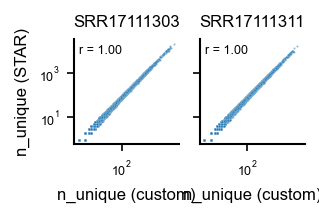

In [16]:
g = sns.relplot(
    kind="scatter",
    data=X,
    x="n_unique_custom",
    y="n_unique_star",
    col="sample",
    s=1, alpha=0.5,
    height=3.5*cm, aspect=0.8
)

for ax in g.axes.flat:
    for coll in ax.collections:
        coll.set_rasterized(True)

for sample, ax in g.axes_dict.items():
    d = X.loc[X["sample"] == sample, ["n_unique_custom","n_unique_star"]].dropna()
    r, p = pearsonr(d["n_unique_custom"], d["n_unique_star"])
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )

g.set(xlabel="n_unique (custom)", ylabel="n_unique (STAR)", xscale="log", yscale="log")
g.set_titles("{col_name}")

g.fig.savefig(os.path.join(FIGS_DIR,"n_unique_star_vs_custom-scatter.pdf"), bbox_inches="tight", dpi=200)

plt.show()

In [14]:
X.sort_values("diff_n_unique", ascending=False).head(20)

,sample,chrom,intron_start,intron_end,strand_code,n_unique_star,n_multi_star,n_unique_custom,n_multi_custom,diff_n_unique
59339,SRR17111311,chr1,248914560,248916601,1,1,0,1,0,0
0,SRR17111303,chr1,11845,12009,1,0,1,0,2,0
1,SRR17111303,chr1,13115,183634,1,1,2,1,2,0
59336,SRR17111311,chr1,248913880,248914438,1,1,0,1,0,0
3,SRR17111303,chr1,14830,15795,2,0,1,0,1,0
4,SRR17111303,chr1,14830,186316,2,0,3,0,4,0
5,SRR17111303,chr1,15039,15795,2,11,73,11,95,0
6,SRR17111303,chr1,15948,16606,2,0,2,0,3,0
7,SRR17111303,chr1,16311,16606,2,1,0,1,0,0
59289,SRR17111311,chr1,248803188,248803269,2,0,1,0,2,0


## Expected mismatches

Junction coverage (chr1, both samples)
  STAR only   : 565,857
  custom only : 3,563
  shared      : 59,341

Shared junctions where n_multi_custom > n_multi_star: 19.3%
Median n_multi_custom / n_multi_star (junctions with n_multi_star > 0): 1.30



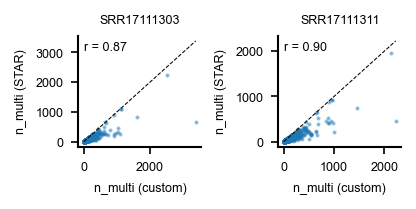

In [15]:
KEY = ["sample","chrom","intron_start","intron_end","strand_code"]

# ── 1. Junction coverage ──────────────────────────────────────────────────────
star_keys  = set(map(tuple, star[KEY].values.tolist()))
custom_keys = set(map(tuple, custom[KEY].values.tolist()))

n_star_only   = len(star_keys - custom_keys)
n_custom_only = len(custom_keys - star_keys)
n_shared      = len(star_keys & custom_keys)

print("Junction coverage (chr1, both samples)")
print(f"  STAR only   : {n_star_only:,}")
print(f"  custom only : {n_custom_only:,}")
print(f"  shared      : {n_shared:,}")
print()

# ── 2. n_multi comparison on shared junctions ────────────────────────────────
X = pd.merge(
    star[KEY + ["n_unique","n_multi"]].rename(columns={"n_unique":"n_unique_star","n_multi":"n_multi_star"}),
    custom[KEY + ["n_unique","n_multi"]].rename(columns={"n_unique":"n_unique_custom","n_multi":"n_multi_custom"}),
    on=KEY,
    how="inner",
)

# fraction of shared junctions where custom n_multi > star n_multi
n_multi_higher = (X["n_multi_custom"] > X["n_multi_star"]).mean()
print(f"Shared junctions where n_multi_custom > n_multi_star: {n_multi_higher:.1%}")

# ratio per junction (cap at 10 for display)
X["n_multi_ratio"] = (X["n_multi_custom"] / X["n_multi_star"].replace(0, float("nan"))).clip(upper=10)
print(f"Median n_multi_custom / n_multi_star (junctions with n_multi_star > 0): "
      f"{X['n_multi_ratio'].median():.2f}")
print()

# ── 3. Scatter: n_multi ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(2 * 3.5 * cm, 3.5 * cm))

for ax, sample in zip(axes, X["sample"].unique()):
    d = X.loc[X["sample"] == sample, ["n_multi_custom", "n_multi_star"]].dropna()
    ax.scatter(d["n_multi_custom"], d["n_multi_star"], s=1, alpha=0.4)
    lim = max(d.max().max(), 1)
    ax.plot([0, lim], [0, lim], "k--", lw=0.5)
    r, _ = pearsonr(d["n_multi_custom"], d["n_multi_star"])
    ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes, ha="left", va="top", fontsize=6)
    ax.set_title(sample, fontsize=6)
    ax.set_xlabel("n_multi (custom)", fontsize=6)
    ax.set_ylabel("n_multi (STAR)", fontsize=6)

fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "n_multi_star_vs_custom-scatter.pdf"), bbox_inches="tight", dpi=200)
plt.show()

## Summary of expected mismatches

| Mismatch | Direction | Root cause |
|---|---|---|
| **n_unique** | custom ≈ STAR (±1–6) | pysam NH=1 vs STAR internal counter; small edge cases (soft-clipped reads near splice sites, chimeric reads) cause single-digit differences |
| **n_multi** | custom > STAR (systematically) | STAR counts multi-mapped *reads* (once per read at the primary alignment); regtools counts all *primary-flagged alignment records*. When STAR writes multiple primary records for a multi-mapped read (`--outSAMprimaryFlag AllBestScore`), regtools counts each one separately, inflating `n_total` and therefore `n_multi_custom = regtools_total − pysam_NH1` |
| **STAR-only junctions** | — | Junctions supported only by reads lacking the XS tag (non-canonical splice motifs) or with anchor < `--min-overhang` are invisible to regtools but recorded in STAR's two-pass SJ.out.tab |
| **custom-only junctions** | — | Regtools can detect junctions in reads that STAR's junction reporter filters (e.g. very long introns flagged as "genomic"); also includes novel junctions found in secondary alignments that STAR does not report |
| **max_overhang** | custom > STAR | STAR reports the maximum overhang across uniquely-mapped reads only; regtools computes it from all reads including multi-mappers, which may span further into the exon |